# 1. Project Background

Today, workplace burnout is increasingly referred to as "The Great Exhaustion". A 2024 study by Mercer found that 8 out of 10 employees are at risk of burnout, highlighting a critical challenge for organizations worldwide. In response, Human Resource (HR) departments are seeking data-driven ways to monitor and manage employee wellbeing.

This project addresses that need by developing a machine learning model to predict employee burnout rates using variables such as gender, working hours per day, job designation, and other relevant features. By leveraging predictive analytics, the model empowers organizations with actionable insights to identify at-risk employees early and foster a healthier, more supportive workplace.

# 2. Load Libraries & Data

In [1]:
# General Libraries
import warnings
import itertools
import random

# Data Analysis & Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mn

# Data Preparation & Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder, LabelBinarizer, MinMaxScaler,
    RobustScaler, StandardScaler, PolynomialFeatures
)
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.pipeline import make_pipeline

# Class Imbalance Handling
from imblearn.over_sampling import SMOTE

# Model Evaluation
from sklearn.metrics import mean_squared_error, make_scorer

# Machine Learning Models
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

# Miscellaneous
from collections import Counter

# Warning and Plot Settings
warnings.filterwarnings("ignore")
%matplotlib inline


In [2]:
# Load the training dataset from the 'dataset' subfolder
employee_df = pd.read_csv("dataset/train.csv")

# Display the first few rows of the dataset
employee_df.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


# 3. Exploratory Data Analysis

### 3.1 Missingness

In [3]:
employee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           22750 non-null  object 
 1   Date of Joining       22750 non-null  object 
 2   Gender                22750 non-null  object 
 3   Company Type          22750 non-null  object 
 4   WFH Setup Available   22750 non-null  object 
 5   Designation           22750 non-null  float64
 6   Resource Allocation   21369 non-null  float64
 7   Mental Fatigue Score  20633 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.6+ MB


From the missing values summary, we observe that only three features, including the target variable, contain missing values. This suggests the dataset is relatively clean, and only targeted imputation or filtering will be required during preprocessing.

<Axes: >

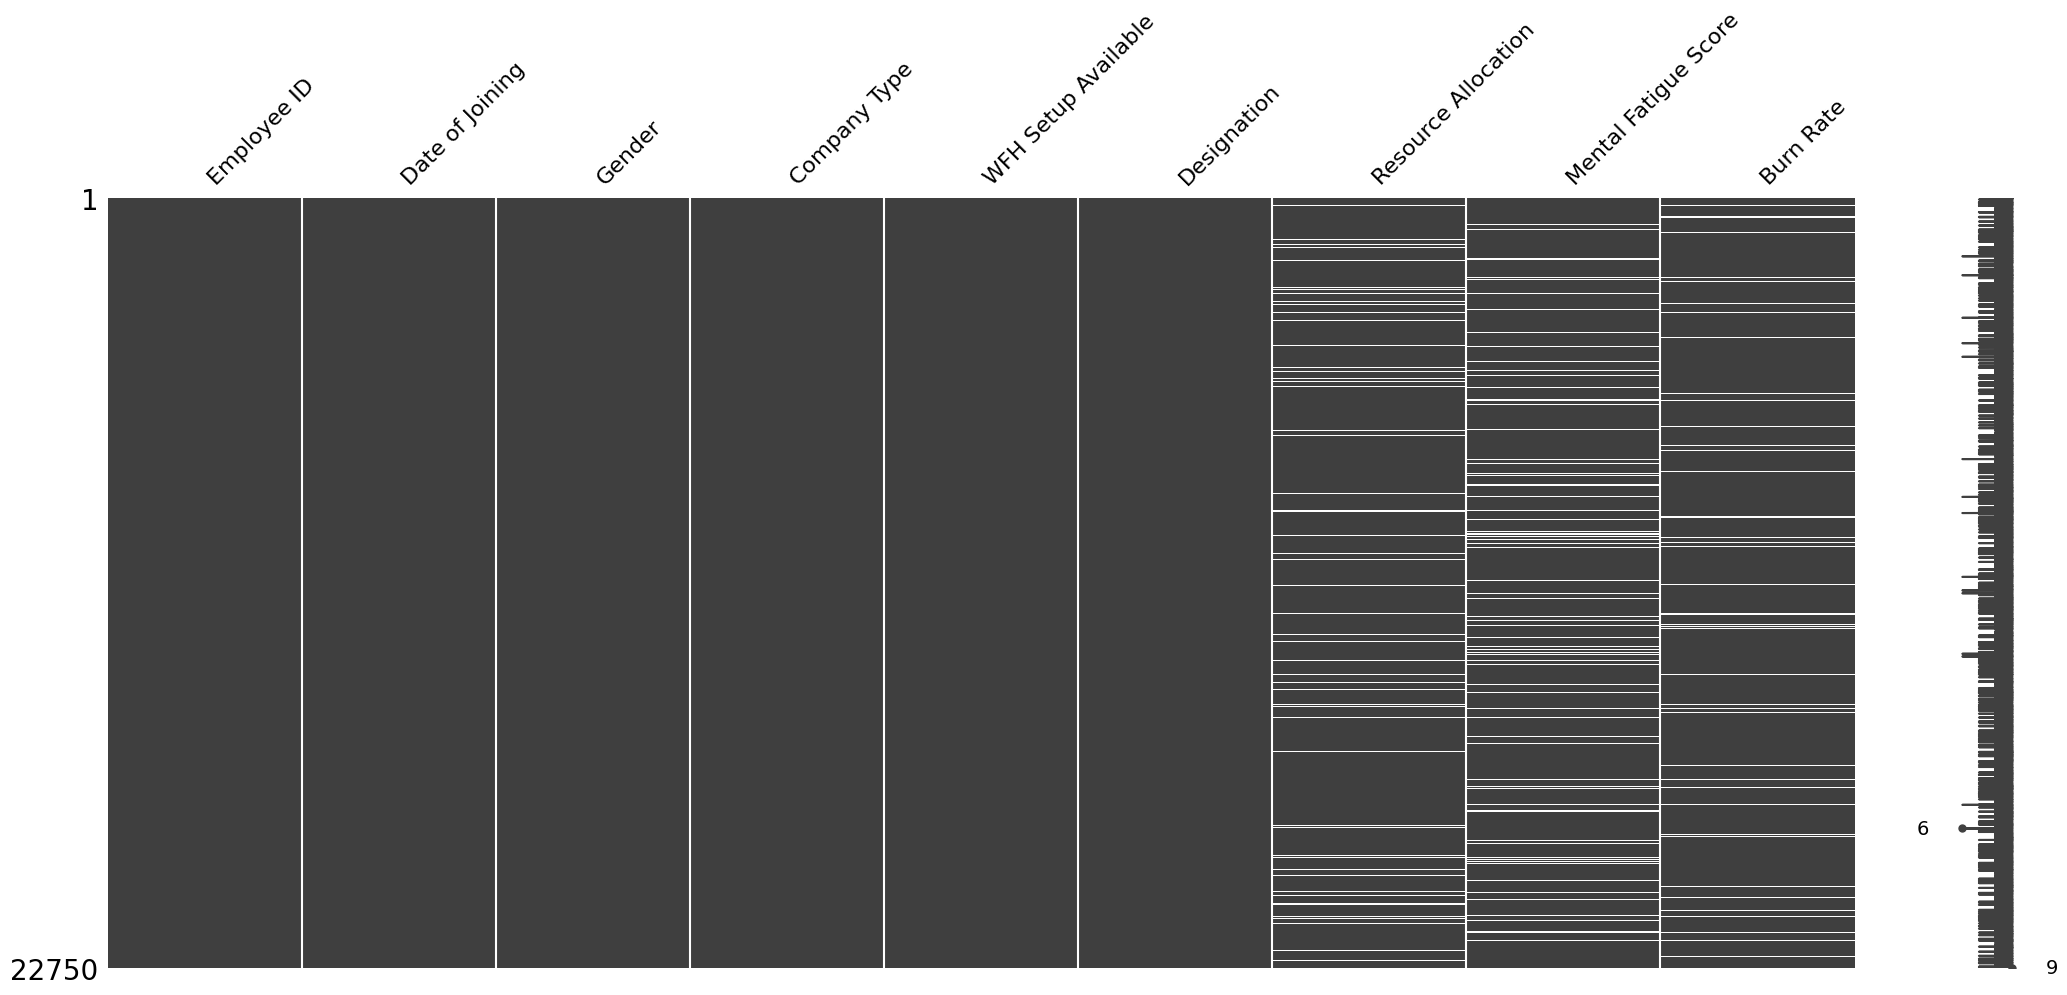

In [4]:
# 🔍 Visualize the location and structure of missing values in the dataset
mn.matrix(employee_df)

It is not advisable to impute rows with missing target variable, so drop all rows where the target variable is missing

In [5]:
# 🧹 Drop rows where the target variable 'Burn Rate' is missing
employee_df.dropna(subset=['Burn Rate'], inplace=True)

We now need to calculate the proportion of missing values in each column that contains missing data. This will help us make an informed decision on whether to drop those columns or impute the missing values.

In [6]:
# 🔍 Step 1: Calculate total missing values per column
total_missing = employee_df.isnull().sum().sort_values(ascending=False)

# 📊 Step 2: Calculate proportion of missing values per column
percent_missing = total_missing / len(employee_df)

# 🧱 Step 3: Combine total and percentage into a single DataFrame
missing_df = pd.concat([total_missing, percent_missing], axis=1, keys=['total_missing', 'percentage_missing'])

# 🏷️ Step 4: Rename index to 'variable' for clarity
missing_df.index.name = 'variable'

# 🧹 Step 5: Filter to retain only variables with missing data
missing_df = missing_df[missing_df['total_missing'] > 0]

# 📐 Step 6: Convert proportion to percentage format
missing_df['percentage_missing'] = missing_df['percentage_missing'].map(lambda x: round(x * 100, 2))

# 👁️ Final: Display the summary
missing_df


,total_missing,percentage_missing
variable,,
Mental Fatigue Score,1945,8.99
Resource Allocation,1278,5.91


Since each column contains only a small proportion of missing values, we can proceed with imputation rather than dropping any features.

To determine the most appropriate imputation strategy, we will first explore the distribution of each variable that contains missing data.

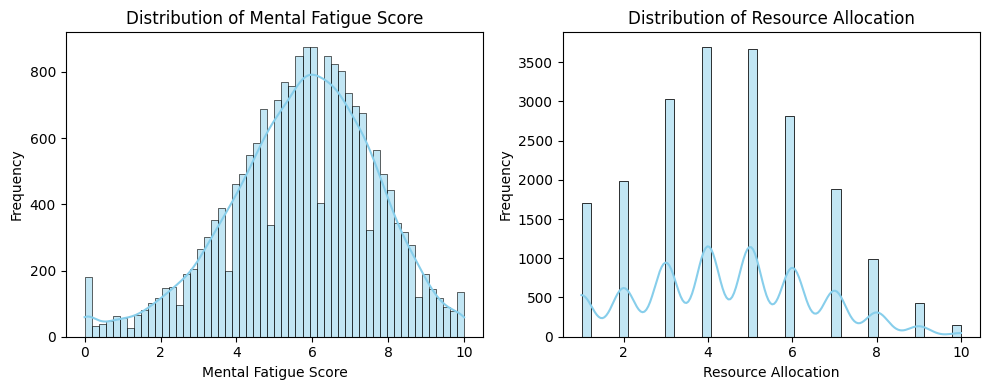

In [7]:
# 🎯 Variables with missing values to visualize
columns_to_plot = ['Mental Fatigue Score', 'Resource Allocation']

# 📐 Create subplots to compare distributions
fig = plt.figure(figsize=(10, 4))

for i, column in enumerate(columns_to_plot):
    ax = fig.add_subplot(1, 2, i + 1)  # 1 row, 2 columns of plots
    sns.histplot(employee_df[column], kde=True, ax=ax, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribution of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Insights from distribution plots:

The variable Mental Fatigue Score displays a roughly normal distribution, making the mean an appropriate choice for imputing its missing values.

Resource Allocation, on the other hand, exhibits a multi-modal (peaked) distribution, suggesting that median imputation would be more robust and less sensitive to skewed values or outliers.

In [8]:
# 🧠 Impute missing values in 'Mental Fatigue Score' using the mean (suitable for normally distributed data)
employee_df['Mental Fatigue Score'].fillna(employee_df['Mental Fatigue Score'].mean(), inplace=True)

# ⚖️ Impute missing values in 'Resource Allocation' using the median (more robust for multi-modal/skewed distributions)
employee_df['Resource Allocation'].fillna(employee_df['Resource Allocation'].median(), inplace=True)

# ℹ️ Confirm that imputation was successful
employee_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21626 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           21626 non-null  object 
 1   Date of Joining       21626 non-null  object 
 2   Gender                21626 non-null  object 
 3   Company Type          21626 non-null  object 
 4   WFH Setup Available   21626 non-null  object 
 5   Designation           21626 non-null  float64
 6   Resource Allocation   21626 non-null  float64
 7   Mental Fatigue Score  21626 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.6+ MB


### 3.2 Outliers

In [9]:
# 🔍 Separate the dataset into numerical and categorical subsets

# All numeric (int, float) columns
num_df = employee_df.select_dtypes(include=[np.number])

# All categorical (object or string-based) columns
cat_df = employee_df.select_dtypes(include=['object'])

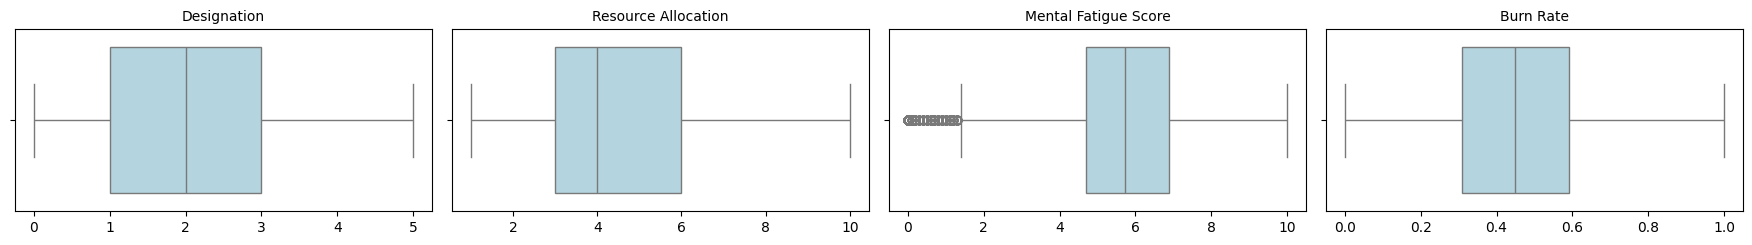

In [10]:
# 📊 Visualize the distribution and detect outliers in all numerical features using boxplots

fig = plt.figure(figsize=(22, 20))  # Set overall figure size

for i in range(len(num_df.columns)):
    ax = fig.add_subplot(9, 5, i + 1)  # Create a grid layout of subplots
    sns.boxplot(x=num_df.iloc[:, i], ax=ax, color='lightblue')
    ax.set_title(num_df.columns[i], fontsize=10)
    ax.set_xlabel('')  # Optional: remove x-labels to declutter

plt.tight_layout()
plt.show()

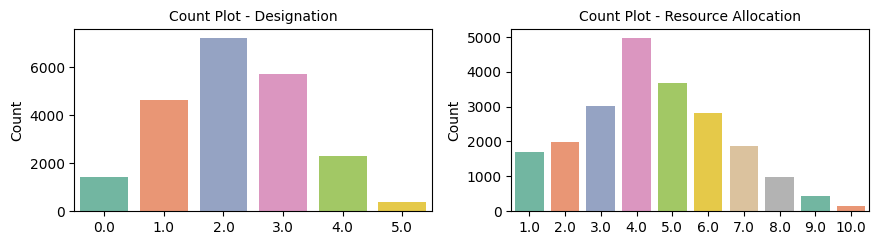

In [11]:
# 📊 Visualize the frequency distribution of selected discrete numerical features using count plots

cols_to_plot = ['Designation', 'Resource Allocation']  # Targeted discrete numeric features
fig = plt.figure(figsize=(22, 20))  # Set figure size

for i, column in enumerate(num_df.columns):
    if column in cols_to_plot:
        ax = fig.add_subplot(9, 5, i + 1)
        sns.countplot(x=employee_df[column], ax=ax, palette='Set2')
        ax.set_title(f'Count Plot - {column}', fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

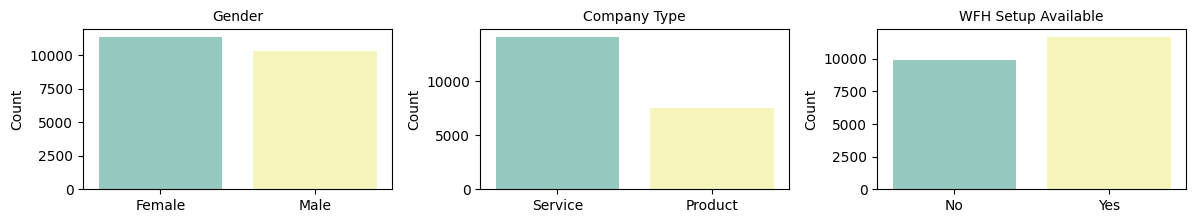

In [12]:
# 🧹 Drop non-informative or irrelevant categorical columns
cat_df.drop(['Employee ID', 'Date of Joining'], axis=1, inplace=True)

# 📊 Plot count distributions for all remaining categorical features
fig = plt.figure(figsize=(20, 18))

for i in range(len(cat_df.columns)):
    ax = fig.add_subplot(9, 5, i + 1)
    sns.countplot(x=cat_df.iloc[:, i], ax=ax, palette='Set3')
    ax.set_title(cat_df.columns[i], fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

### 3.3 Correlation

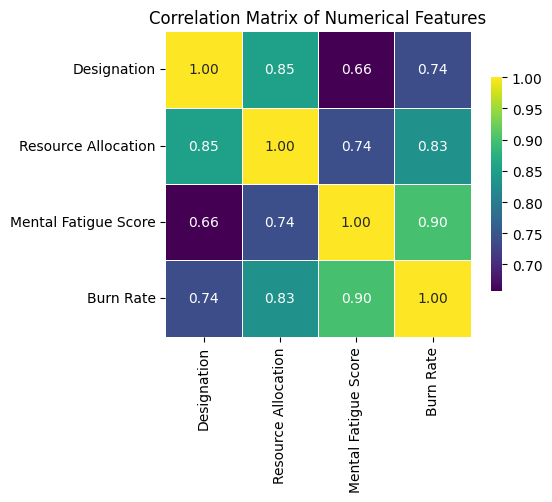

In [13]:
# 🔗 Compute the correlation matrix for all numerical features
corrmat = num_df.corr()

# 🎯 Plot the heatmap to visualize pairwise correlations
plt.figure(figsize=(6, 5))  # Slightly wider for better readability
sns.heatmap(corrmat, annot=True, fmt=".2f", cmap="viridis", linewidths=0.5, square=True, cbar_kws={"shrink": .7})
plt.title("Correlation Matrix of Numerical Features", fontsize=12)
plt.tight_layout()
plt.show()

### 3.4 Bivariate Analysis

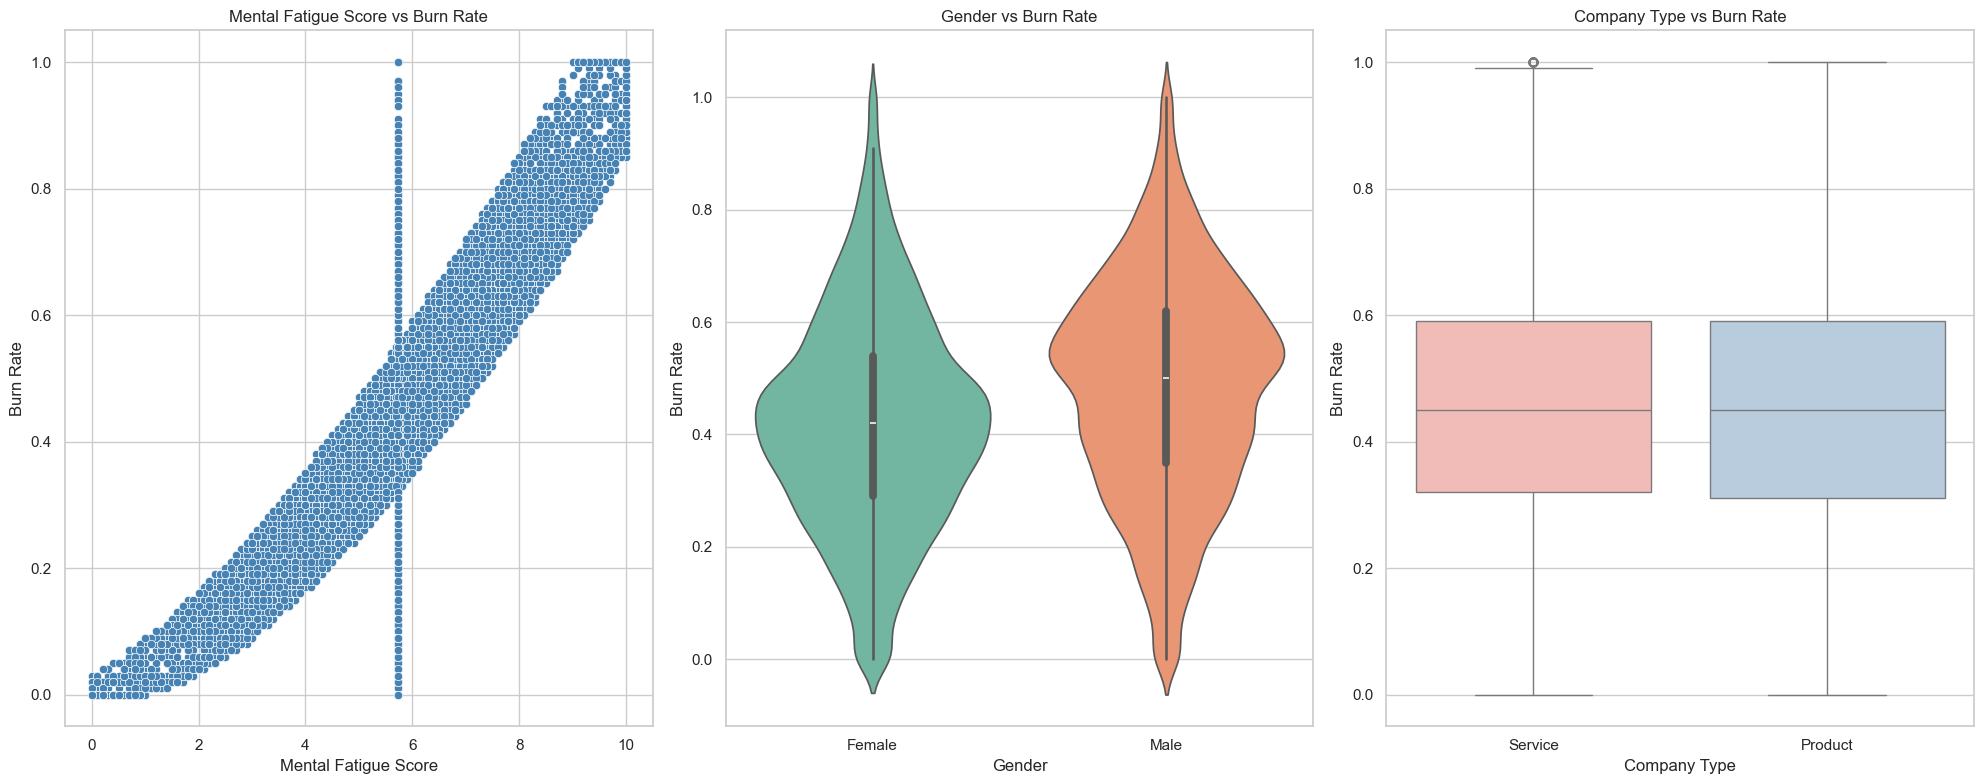

In [14]:
# 📊 Analyze relationships between Burn Rate and key features:
# - Mental Fatigue Score (continuous)
# - Gender (categorical)
# - Company Type (categorical)

sns.set(style="whitegrid")

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 8))  # Create 3 side-by-side plots

# 🔹 Scatter plot: Mental Fatigue Score vs Burn Rate
ax[0].set_title("Mental Fatigue Score vs Burn Rate")
sns.scatterplot(x='Mental Fatigue Score', y='Burn Rate', data=employee_df, ax=ax[0], color='steelblue')
ax[0].set_xlabel('Mental Fatigue Score')
ax[0].set_ylabel('Burn Rate')

# 🔹 Violin plot: Gender vs Burn Rate
ax[1].set_title("Gender vs Burn Rate")
sns.violinplot(x='Gender', y='Burn Rate', data=employee_df, ax=ax[1], palette="Set2")
ax[1].set_xlabel('Gender')
ax[1].set_ylabel('Burn Rate')

# 🔹 Box plot: Company Type vs Burn Rate
ax[2].set_title("Company Type vs Burn Rate")
sns.boxplot(x='Company Type', y='Burn Rate', data=employee_df, ax=ax[2], palette="Pastel1")
ax[2].set_xlabel('Company Type')
ax[2].set_ylabel('Burn Rate')

plt.tight_layout()
plt.show()

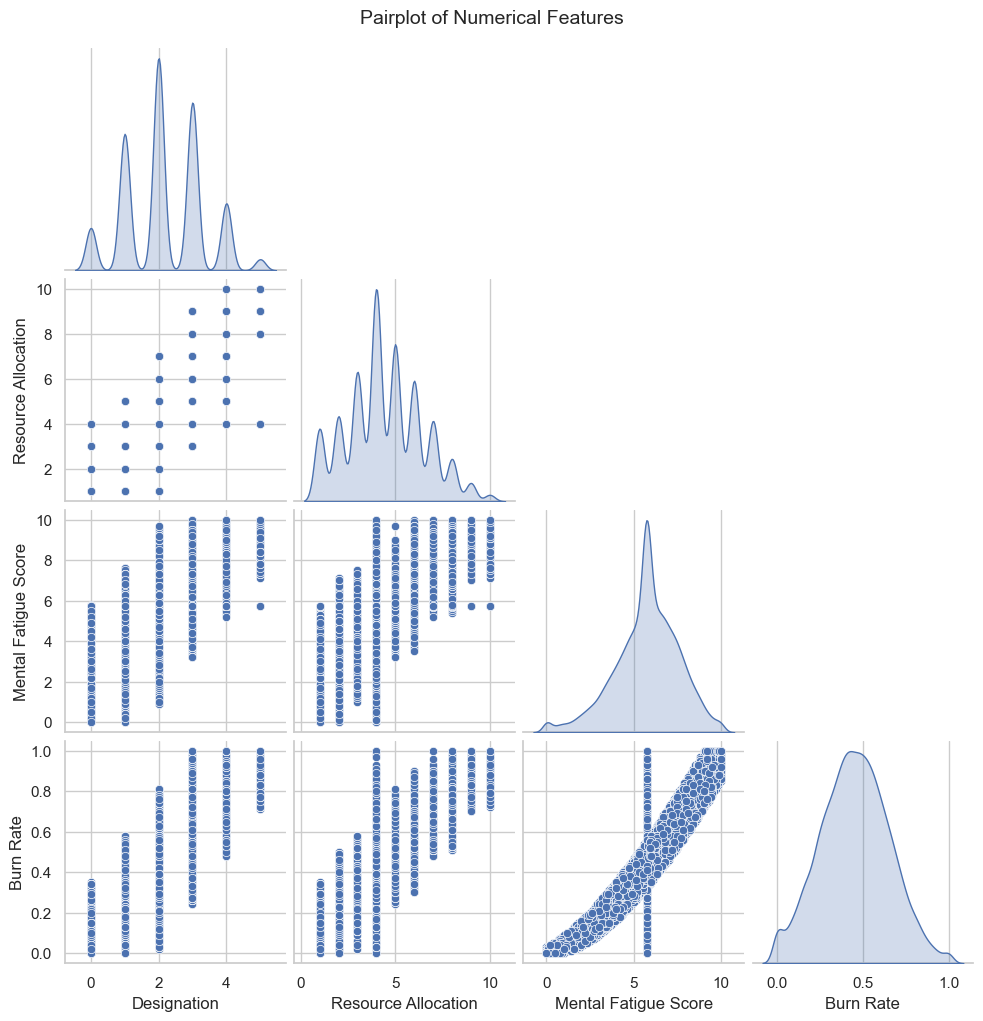

In [15]:
# 📈 Pairwise relationships and distributions of all numerical features
sns.pairplot(num_df, diag_kind='kde', corner=True)
plt.suptitle("Pairplot of Numerical Features", fontsize=14, y=1.02)
plt.show()

### 📊 **Insights from Bivariate Analysis**

1. **Positive Correlation with Mental Fatigue:**
   Burnout rate increases with higher mental fatigue scores, indicating a strong positive relationship between the two variables.

2. **Burnout Rate Distribution by Gender:**
   For both male and female employees, the majority have a burnout rate concentrated between **0.4 and 0.6**, suggesting gender does not strongly differentiate burnout levels in this range.

3. **Company Type Comparison:**
   The difference in burnout rates between employees in **service-based** and **product-based** companies is minimal, implying company type has limited influence on average burnout levels.

# 4. Data Preprocessing

### 4.1 Feature Engineering

To enrich the dataset, we derive a new feature called **`Tenure`**, representing the number of years each employee has been with the company up to the current date.

> **Note:** It is assumed that burnout data was collected in **2025** (i.e., the current year), and thus tenure is calculated as the difference between 2025 and each employee’s year of joining.

In [16]:
# 📅 Step 1: Convert 'Date of Joining' column to datetime format
employee_df['Date of Joining'] = pd.to_datetime(employee_df['Date of Joining'])

# 📆 Step 2: Get today's date (assumed to be current system date)
from datetime import datetime
today = datetime.now()

# 🔁 Step 3: Define a function to compute total months of tenure
def calculate_tenure(join_date):
    """Calculate the number of months between join_date and today."""
    total_months = (today.year - join_date.year) * 12 + (today.month - join_date.month)
    return total_months

# 🧮 Step 4: Apply function to create a new 'Tenure (Months)' feature
employee_df['Tenure (Months)'] = employee_df['Date of Joining'].apply(calculate_tenure)

In [17]:
# 🧮 Compute employee tenure in months from 'Date of Joining'
employee_df['Tenure_in_months'] = employee_df['Date of Joining'].apply(calculate_tenure)

# 🔍 Preview the new column
employee_df.head(20)

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Tenure (Months),Tenure_in_months
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.800000,0.16,201,201
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.000000,0.36,199,199
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,4.0,5.800000,0.49,207,207
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.600000,0.20,199,199
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.900000,0.52,203,203
5,fffe3300350037003500,2008-11-26,Male,Product,Yes,2.0,4.0,3.600000,0.29,199,199
6,fffe33003300340039003100,2008-01-02,Female,Service,No,3.0,6.0,7.900000,0.62,209,209
7,fffe32003600320037003400,2008-10-31,Female,Service,Yes,2.0,4.0,4.400000,0.33,200,200
8,fffe32003200300034003700,2008-12-27,Female,Service,No,3.0,6.0,5.729851,0.56,198,198
9,fffe31003600320030003200,2008-03-09,Female,Product,No,3.0,6.0,5.729851,0.67,207,207


In [18]:
# 🔍 Summary of missing values per column
employee_df.isnull().sum().sort_values(ascending=False)

Employee ID             0
Date of Joining         0
Gender                  0
Company Type            0
WFH Setup Available     0
Designation             0
Resource Allocation     0
Mental Fatigue Score    0
Burn Rate               0
Tenure (Months)         0
Tenure_in_months        0
dtype: int64

### 4.2 Data Encoding

We will use **One-Hot Encoding** to transform the categorical variables.
This approach is appropriate here because:

* The number of categorical columns is relatively small.
* Most categorical features have a manageable number of unique values, avoiding the risk of a high-dimensional sparse matrix.

In [19]:
# 🔄 Initialize OneHotEncoder (non-sparse output for DataFrame conversion)
ohe = OneHotEncoder(sparse_output=False)

# 🔠 Fit and transform the categorical dataframe
ohe_transformed = ohe.fit_transform(cat_df)

# 🧱 Convert encoded data to a DataFrame with original indices and appropriate column names
encoded_df = pd.DataFrame(ohe_transformed, 
                          columns=ohe.get_feature_names_out(cat_df.columns),
                          index=cat_df.index)

# 🧬 Combine encoded features with original data
final_df = pd.concat([employee_df, encoded_df], axis=1)

# 🧹 Drop original categorical columns (now represented by encoded versions)
final_df.drop(['Employee ID', 'Gender', 'Date of Joining', 'Company Type', 'WFH Setup Available'], 
              axis=1, inplace=True)

# 🔍 Final check for missing values
final_df.isnull().sum()

Designation                0
Resource Allocation        0
Mental Fatigue Score       0
Burn Rate                  0
Tenure (Months)            0
Tenure_in_months           0
Gender_Female              0
Gender_Male                0
Company Type_Product       0
Company Type_Service       0
WFH Setup Available_No     0
WFH Setup Available_Yes    0
dtype: int64

# 5. Modelling with preprocessed data

#### 🎯 Problem Type: Regression

Since **burnout rate** is a continuous variable, predicting it based on employee-related metrics constitutes a **regression problem**.

To model this, we will implement and compare the performance of the following algorithms:

1. **Linear Regression** – a simple, interpretable baseline model.
2. **Support Vector Regression (SVR)** – capable of capturing non-linear relationships using kernels.
3. **Random Forest Regressor** – a powerful ensemble method that handles complex interactions and non-linearities well.

In [20]:
# 🎯 Define feature matrix (X) and target vector (y)
X = final_df.drop('Burn Rate', axis=1)      # All predictors
y = final_df[['Burn Rate']]                 # Target variable as a DataFrame

In [21]:
# 🧪 Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=20
)

# 📏 Check shapes to confirm successful split
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

X_train shape: (17300, 11)
X_test shape : (4326, 11)
y_train shape: (17300, 1)
y_test shape : (4326, 1)


In [22]:
# ⚖️ Initialize the scaler
scaler = StandardScaler()

# ✅ Fit on training data and transform both sets
X_train = scaler.fit_transform(X_train)  # Fit + transform on training set
X_test = scaler.transform(X_test)        # Only transform on test set


In [23]:
# 📌 Initialize the model
reg = LinearRegression()

# 📊 Evaluate using 5-fold cross-validation with MSE
# Note: cross_val_score uses *negative* MSE because it assumes higher scores are better
neg_mse_scores = cross_val_score(reg, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

# 🔁 Convert negative scores back to positive MSE
mse_scores = -neg_mse_scores

# 📈 Output individual scores and their mean
print("MSE Scores for each fold:", mse_scores)
print("Average MSE:", mse_scores.mean())

MSE Scores for each fold: [0.0049329  0.00480563 0.00549759 0.00478655 0.00512344]
Average MSE: 0.005029219716453081


In [24]:
# 🧱 Initialize Lasso model
las_model = Lasso()

# 🧪 Apply 5-fold CV using negative MSE (as required by sklearn)
neg_mse_scores = cross_val_score(las_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

# 🔁 Convert to positive MSE
mse_scores = -neg_mse_scores

# 📊 Display scores
print("MSE Scores for each fold (Lasso):", mse_scores)
print("Average MSE (Lasso):", mse_scores.mean())

MSE Scores for each fold (Lasso): [0.03878431 0.04017774 0.03918127 0.03978718 0.03896089]
Average MSE (Lasso): 0.03937827577287079


In [25]:
# ⚙️ Initialize SVR model
svr_model = SVR()

# 🔍 Perform 5-fold CV using negative MSE
neg_mse_scores = cross_val_score(svr_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

# ✅ Convert negative MSE to positive
mse_scores = -neg_mse_scores

# 📊 Display results
print("MSE Scores for each fold (SVR):", mse_scores)
print("Average MSE (SVR):", mse_scores.mean())

MSE Scores for each fold (SVR): [0.00441634 0.00437909 0.00466782 0.00430711 0.00458816]
Average MSE (SVR): 0.004471705517453102


In [26]:
# 🌲 Initialize Random Forest Regressor
rfr = RandomForestRegressor(random_state=42)

# 🧪 Perform 5-fold CV using negative MSE
neg_mse_scores = cross_val_score(rfr, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

# ✅ Convert to positive MSE
mse_scores = -neg_mse_scores

# 📊 Display results
print("MSE Scores for each fold (Random Forest):", mse_scores)
print("Average MSE (Random Forest):", mse_scores.mean())

MSE Scores for each fold (Random Forest): [0.00433059 0.00425912 0.00454472 0.00421421 0.00435868]
Average MSE (Random Forest): 0.004341462970200901


#### 🔍 Model Selection for Hyperparameter Tuning

Among the evaluated models, **Support Vector Regressor (SVR)** and **Random Forest Regressor (RFR)** demonstrated the lowest mean squared error (MSE) scores—indicating better performance in predicting the burnout rate. Since lower MSE values are desirable in regression tasks (with values closer to 0 being optimal), we will proceed with hyperparameter tuning for these two models to further optimize their predictive performance.

# 6. HyperParameter Tuning

#### Using GridSearch CV

In [27]:
# 🧠 Initialize the model
rf_model = RandomForestRegressor(random_state=42)

# 🛠️ Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# 🔍 Initialize GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=2
)

# 🚀 Fit the model to training data
grid_search_rf.fit(X_train, y_train)

# ✅ Extract and display best parameters and score
best_rf_params = grid_search_rf.best_params_
best_rf_score = -grid_search_rf.best_score_

print(f"🔧 Best Hyperparameters (Random Forest): {best_rf_params}")
print(f"📉 Best MSE Score (Random Forest): {best_rf_score:.4f}")

Fitting 3 folds for each of 216 candidates, totalling 648 fits
🔧 Best Hyperparameters (Random Forest): {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
📉 Best MSE Score (Random Forest): 0.0036


In [28]:
# 🧠 Initialize the model
svr_model = SVR()

# 🛠️ Define the hyperparameter grid
param_grid = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto'],
    'epsilon': [0.1, 0.2, 0.5, 1.0]
}

# 🔍 Initialize GridSearchCV
grid_search_svr = GridSearchCV(
    estimator=svr_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=2
)

# 🚀 Fit the model to training data
grid_search_svr.fit(X_train, y_train.values.ravel())  # .ravel() to flatten y into 1D

# ✅ Extract and display best parameters and score
best_svr_params = grid_search_svr.best_params_
best_svr_score = -grid_search_svr.best_score_

print(f"🔧 Best Hyperparameters (SVR): {best_svr_params}")
print(f"📉 Best MSE Score (SVR): {best_svr_score:.4f}")


Fitting 3 folds for each of 128 candidates, totalling 384 fits
🔧 Best Hyperparameters (SVR): {'C': 1, 'epsilon': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
📉 Best MSE Score (SVR): 0.0045


# 6 Model Evaluation

In [29]:
# ✅ Best hyperparameters from GridSearchCV
best_rfr_params = {
    'bootstrap': True,
    'max_depth': 10,
    'min_samples_leaf': 1,
    'min_samples_split': 10,
    'n_estimators': 200
}

# 🚀 Initialize and train the model with optimized hyperparameters
best_rfr_model = RandomForestRegressor(**best_rfr_params, random_state=42)
best_rfr_model.fit(X_train, y_train.values.ravel())

# 📈 Make predictions
y_pred = best_rfr_model.predict(X_test)

# 📉 Evaluate model performance
mse_rfr = mean_squared_error(y_test, y_pred)
print(f"📊 Mean Squared Error (Optimized Random Forest): {mse_rfr:.4f}")

📊 Mean Squared Error (Optimized Random Forest): 0.0039


In [30]:
# ✅ Best hyperparameters from GridSearchCV
best_svr_params = {
    'C': 1,
    'epsilon': 0.1,
    'gamma': 'auto',
    'kernel': 'rbf'
}

# 🚀 Initialize and train the model with optimized hyperparameters
best_svr_model = SVR(**best_svr_params)
best_svr_model.fit(X_train, y_train.values.ravel())

# 📈 Make predictions
y_pred_svr = best_svr_model.predict(X_test)

# 📉 Evaluate model performance
mse_svr = mean_squared_error(y_test, y_pred_svr)
print(f"📊 Mean Squared Error (Optimized SVR): {mse_svr:.4f}")

📊 Mean Squared Error (Optimized SVR): 0.0047


### 🔍 Insights from Hyperparameter Tuning and Evaluation

* **Random Forest Regressor**

  * Baseline MSE: **0.0043**
  * Tuned MSE: **0.0039**
  * *Interpretation:* The modest reduction in MSE after tuning suggests that the default hyperparameters were already well-suited to the data. Further tuning provided only marginal benefit and introduced a risk of slight overfitting to the cross-validation folds.

* **Support Vector Regressor**

  * Baseline MSE: **0.0044**
  * Tuned MSE: **0.0047**
  * *Interpretation:* In this instance, hyperparameter tuning resulted in a slight increase in MSE. This outcome indicates that the selected search space may not have been advantageous and may have led to mild overfitting.

* **Key Takeaways**

  * Both models exhibit **very low MSE values**, demonstrating strong predictive accuracy and good generalization to unseen data.
  * These findings underscore the importance of **validating hyperparameter tuning against a baseline**, as tuning does not inherently guarantee improved performance. Careful definition of the search space and avoidance of unnecessary complexity are critical to prevent overfitting and inefficient use of computational resources.

### ✅ Conclusion

These slight differences in MSE do not matter in this context.

The differences in mean squared error between the models—ranging from **0.0036 to 0.0047** are minimal and fall within a margin unlikely to affect practical decision-making. Given that the prediction target (burnout rate) is likely on a normalized scale (e.g., 0 to 1), an error difference of less than **0.001** translates to negligible deviation in actual predictions.

Such small differences do not meaningfully change the model’s ability to identify high or low burnout risk. Moreover, they do not justify the extra complexity or computational cost of extensive tuning. Therefore, **both models can be considered equally effective for this task from a performance perspective**.


### Sample prediction using the optimized RandomForestRegressor

In [32]:
# ✅ Train the final model using best parameters
best_rfr = RandomForestRegressor(**best_rf_params, random_state=42)
best_rfr.fit(X_train, y_train)

# 🔍 Take a random sample from the test set
sample_index = np.random.randint(0, X_test.shape[0])
sample_data = X_test[sample_index].reshape(1, -1)

# 🧠 Predict burn rate using the trained RandomForestRegressor
predicted_burnrate = best_rfr.predict(sample_data)

# 🎯 Show prediction vs actual
print(f"Sample index: {sample_index}")
print(f"Predicted Burn Rate: {predicted_burnrate[0]:.4f}")
print(f"Actual Burn Rate: {y_test.iloc[sample_index].values[0]:.4f}")

Sample index: 3252
Predicted Burn Rate: 0.3625
Actual Burn Rate: 0.3400


#### Sample Prediction Script

In [36]:
import joblib

# Load the trained model
model = joblib.load('burnout_predictor_rf_model.pkl')

# Check how many features the model expects
n_features = model.n_features_in_
print(f"Model expects {n_features} features.")

# Example: replace this with real values
# Here we just fill it with example values (0.5 repeated)
sample = np.full((1, n_features), 0.5)

# Make prediction
prediction = model.predict(sample)

# Output result
print(f"Predicted Burn Rate: {prediction[0]:.4f}")

Model expects 11 features.
Predicted Burn Rate: 0.5379
